In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hojjatk/mnist-dataset/train-images.idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-labels.idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-images.idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-labels.idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-images-idx3-ubyte/train-images-idx3-ubyte


# Importing libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
print (torch.__version__)
print ("pytorch libraries imported ...")

2.10.0+cu128
pytorch libraries imported ...


In [3]:
# Checking cuda 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print ("device:",device)
if device.type=="cuda":
    print (f"GPU name: {torch.cuda.get_device_name()}")

device: cuda
GPU name: Tesla T4


***input_dim is used to feed the dimension without using hardcode***

In [4]:
class costumANN(nn.Module):
    def __init__(self,input_dim,output_dim,actfunc):
        super().__init__()
        self.h1 = nn.Linear(input_dim,128)
        self.h2 = nn.Linear(128,64)
        self.h3 = nn.Linear(64,output_dim)
        self.activation =actfunc
        self.input_dim = input_dim
    def forward(self,x,):
        # flatten the input
        x = x.view(-1,self.input_dim)
        # layer 1
        x =self.h1(x)
        x = self.activation(x)
        # layer 2
        x = self.h2(x)
        x = self.activation(x)
        # layer 3
        x = self.h3(x)
        return x
        
    

In [5]:
# exploring the weights, bias and tensor of one layer.
x = torch.randn(1,128)
linear = nn.Linear(128,64)
output = linear(x)
print (f"input shape: {x.shape}")
print (f"output shape: {output.shape}")
print (f" the output tensor:\n {output}")
w = linear.weight
print (f"weights : {w.shape}\n")
b = linear.bias
print (f"bias : {b.shape}")

input shape: torch.Size([1, 128])
output shape: torch.Size([1, 64])
 the output tensor:
 tensor([[-0.3241,  1.2147,  0.7585,  0.6499,  0.3465, -0.2246, -0.4038,  0.5652,
          0.5600,  0.4082, -0.8996,  0.3157, -0.1029, -0.5672, -0.1234,  1.2631,
          0.0537,  0.7493, -0.9646,  0.7016, -0.8173,  0.5687,  0.0526,  0.1047,
         -0.1933, -0.3463, -0.0913, -0.2067,  0.3384, -0.0504, -0.2184, -0.3180,
          0.1127, -0.5677,  0.1627,  1.0888,  0.0082, -0.4837, -0.9271, -0.2735,
          0.3438,  1.0088, -0.0019,  0.5307, -0.2438, -0.1651, -0.3030, -0.2793,
          1.0268,  1.0214, -0.2891, -0.1334, -0.5409,  0.6760,  0.2265,  0.3726,
          1.0737,  0.1751, -0.1717,  0.4177,  0.7213,  0.6466, -0.3024, -0.6224]],
       grad_fn=<AddmmBackward0>)
weights : torch.Size([64, 128])

bias : torch.Size([64])


# Loading and preprocessing Data MNIST

In [6]:
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])



train_dataset = datasets.MNIST(root="./kaggle/input",train=True,download=True,transform=data_transform)
test_dataset = datasets.MNIST(root = "./kaggle/input",train=False,download=True, transform=data_transform)
train_dataloader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_dataloader = DataLoader(test_dataset,batch_size=1000,shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 453kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.32MB/s]


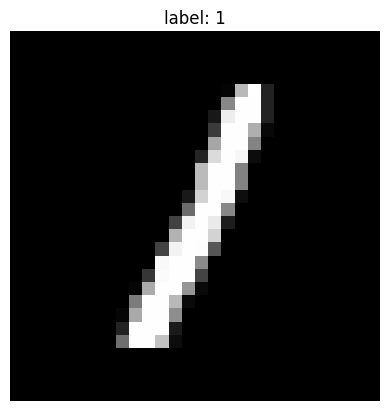

In [7]:
# Exploring train datasloader
dataiter = iter(train_dataloader)
image, label = next(dataiter)
plt.imshow(image[20].squeeze(),cmap="grey")
plt.title(f"label: {label[20].item()}")
plt.axis("off")
plt.show()

# Model train and eval

In [8]:
# train and evaluate the model
def train_eval (model,optimizer, epochs=5):
    loss_criterion = nn.CrossEntropyLoss()
    train_loss= []
    test_accuracy = []
    for epoch in range (epochs):
        # model train
        model.train()
        for batch_idx,(image,label) in enumerate(train_dataloader):
            image, label = image.to(device), label.to(device)
            optimizer.zero_grad()
            output = model(image)
            loss = loss_criterion(output,label)
            loss.backward()
            optimizer.step()
            # printing 
            if batch_idx % 100 == 0:
                print (f"Epoch{epoch+1}/{epochs},Batch {batch_idx}/{len(train_dataloader)},loss: {loss.item():.4f}")
        
        train_loss.append(loss.item())  
        #evaluation of the model train
        model.eval()
        correct = 0
        with torch.no_grad():
            for image, label in test_dataloader:
                image , label = image.to(device),label.to(device)
                output = model(image)
                pred = output.argmax(dim=1,keepdim=True)
                correct += pred.eq(label.view_as(pred)).sum().item()


        accuracy= correct / len(test_dataloader.dataset)
        test_accuracy.append(accuracy)
        # print the test output
        print (f"Epoch: {epoch+1}/{epochs},Test accuracy: {accuracy:4f}")
    return train_loss, test_accuracy
print ("function was created ...")
    


function was created ...


In [9]:
# Applying three activation function
activation_functions = {
    "ReLU":nn.ReLU(),
    "Tanh":nn.Tanh(),
    "Sigmoid":nn.Sigmoid()
}
inputs = 28*28
output = 10
results={}
for key, func in activation_functions.items():
    print (f"\n applying {key} as Activation function")
    model = costumANN(inputs,output,func).to(device)
    optimizer= optim.SGD(model.parameters(),lr=0.01,momentum=0.9)
    losses,accuracies=train_eval(model,optimizer)
    results[key]=(losses,accuracies)
print ("Model training and evaluation completed ...")


 applying ReLU as Activation function
Epoch1/5,Batch 0/1875,loss: 2.2939
Epoch1/5,Batch 100/1875,loss: 0.8096
Epoch1/5,Batch 200/1875,loss: 0.3303
Epoch1/5,Batch 300/1875,loss: 0.4017
Epoch1/5,Batch 400/1875,loss: 0.2198
Epoch1/5,Batch 500/1875,loss: 0.2221
Epoch1/5,Batch 600/1875,loss: 0.0653
Epoch1/5,Batch 700/1875,loss: 0.1408
Epoch1/5,Batch 800/1875,loss: 0.1449
Epoch1/5,Batch 900/1875,loss: 0.0830
Epoch1/5,Batch 1000/1875,loss: 0.1013
Epoch1/5,Batch 1100/1875,loss: 0.0654
Epoch1/5,Batch 1200/1875,loss: 0.2390
Epoch1/5,Batch 1300/1875,loss: 0.2100
Epoch1/5,Batch 1400/1875,loss: 0.2669
Epoch1/5,Batch 1500/1875,loss: 0.0778
Epoch1/5,Batch 1600/1875,loss: 0.0952
Epoch1/5,Batch 1700/1875,loss: 0.0993
Epoch1/5,Batch 1800/1875,loss: 0.0874
Epoch: 1/5,Test accuracy: 0.961600
Epoch2/5,Batch 0/1875,loss: 0.2020
Epoch2/5,Batch 100/1875,loss: 0.0326
Epoch2/5,Batch 200/1875,loss: 0.1285
Epoch2/5,Batch 300/1875,loss: 0.1360
Epoch2/5,Batch 400/1875,loss: 0.0175
Epoch2/5,Batch 500/1875,loss: 0.0

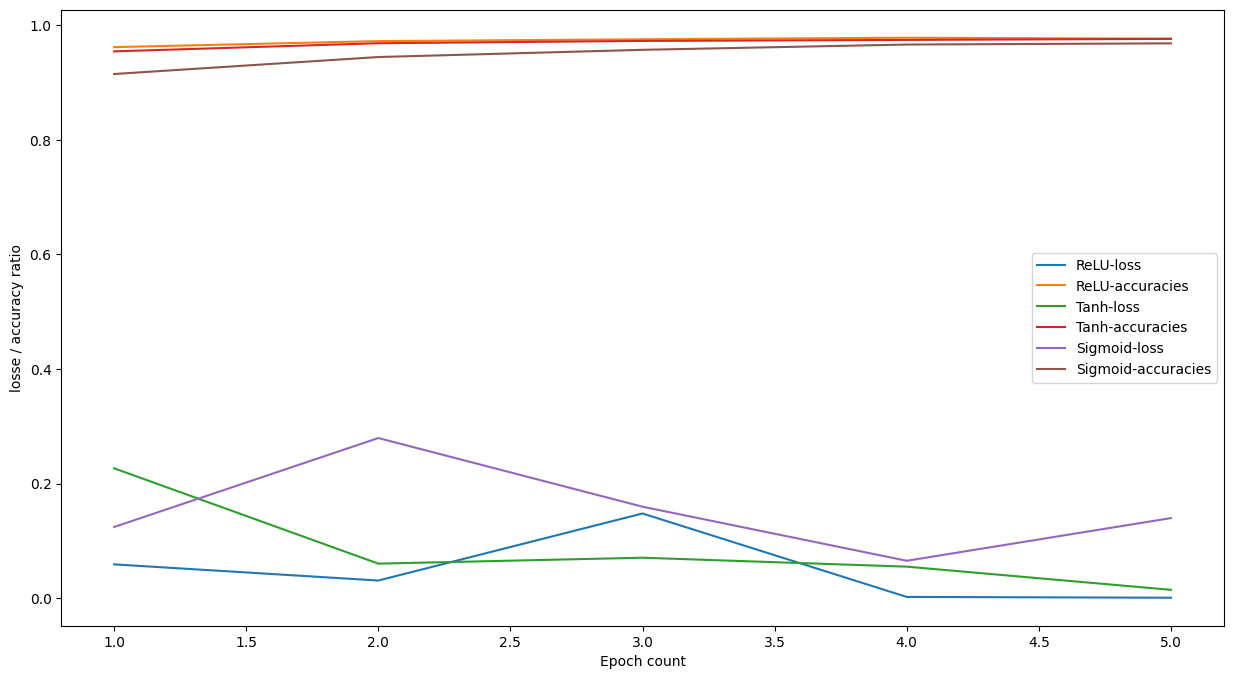

In [10]:
# Visualization
plt.figure(figsize=(15,8))
for key, (losses,accuracies) in results.items():
    plt.plot(range(1,len(losses)+1),losses,label=f"{key}-loss")
    plt.plot(range(1,len(accuracies)+1),accuracies,label=f'{key}-accuracies')
plt.xlabel("Epoch count")
plt.ylabel("losse / accuracy ratio")
plt.legend()
plt.show()

# Prediction

In [11]:
# Prediction function
def prediction(model, input_data):
    '''
    one image prediction
    the model: activation function : ReLU, optimizer: Adam
    '''
    model.eval
    with torch.no_grad():
        output_logits=model(input_data)
        pred = output_logits.argmax(dim=1)
        pred = pred.item()
    return pred
print ("prediction function completed ...")

prediction function completed ...


In [12]:
# train the model, activation function ReLU and optimizer = Adam
inputs = 28*28
output = 10
# Model training
model = costumANN(inputs,output,nn.ReLU()).to(device)
optimizer= optim.Adam(model.parameters(), lr=0.001)
# losses,accuracies=train_eval(model,optimizer)
# results[key]=(losses,accuracies)
train_eval(model,optimizer)
# Obtaining an image sample 
dataiter = iter(test_dataloader)
images, labels = next(dataiter)
image_to_test = images[0]
label_to_test = labels[0].item()
# prediction
predict_image = prediction(model,image_to_test.to(device))
print (f"model prediction: {predict_image}")
print (f"actual label: {label_to_test}")

Epoch1/5,Batch 0/1875,loss: 2.3106
Epoch1/5,Batch 100/1875,loss: 0.2637
Epoch1/5,Batch 200/1875,loss: 0.2303
Epoch1/5,Batch 300/1875,loss: 0.3721
Epoch1/5,Batch 400/1875,loss: 0.5986
Epoch1/5,Batch 500/1875,loss: 0.3749
Epoch1/5,Batch 600/1875,loss: 0.2772
Epoch1/5,Batch 700/1875,loss: 0.2467
Epoch1/5,Batch 800/1875,loss: 0.1857
Epoch1/5,Batch 900/1875,loss: 0.1910
Epoch1/5,Batch 1000/1875,loss: 0.0806
Epoch1/5,Batch 1100/1875,loss: 0.4355
Epoch1/5,Batch 1200/1875,loss: 0.2474
Epoch1/5,Batch 1300/1875,loss: 0.0889
Epoch1/5,Batch 1400/1875,loss: 0.1313
Epoch1/5,Batch 1500/1875,loss: 0.0690
Epoch1/5,Batch 1600/1875,loss: 0.1258
Epoch1/5,Batch 1700/1875,loss: 0.2137
Epoch1/5,Batch 1800/1875,loss: 0.0211
Epoch: 1/5,Test accuracy: 0.956300
Epoch2/5,Batch 0/1875,loss: 0.0595
Epoch2/5,Batch 100/1875,loss: 0.0073
Epoch2/5,Batch 200/1875,loss: 0.1360
Epoch2/5,Batch 300/1875,loss: 0.0458
Epoch2/5,Batch 400/1875,loss: 0.0686
Epoch2/5,Batch 500/1875,loss: 0.0274
Epoch2/5,Batch 600/1875,loss: 0.360